# Titanic Dataset — Exploratory Data Analysis & Preprocessing

| | |
|---|---|
| **Student Name** | Jason Chan |
| **Student ID** | 123 |
| **Assignment** | Classwork — Data Preprocessing |
| **Dataset** | [Titanic Dataset](https://www.kaggle.com/c/titanic/data) |

> **Note:** Code in this notebook was completed with the assistance of [Claude](https://claude.ai) (Anthropic AI).

---

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Setup & Data Loading

In [ ]:
data = pd.read_csv('Titanic-Dataset.csv')
print("Shape:", data.shape)
print("\nColumns:", list(data.columns))
data.head()

## 2. Outlier Detection

Using **boxplots** for visual inspection and the **IQR method** (1.5× rule) to quantify outliers in numerical features.

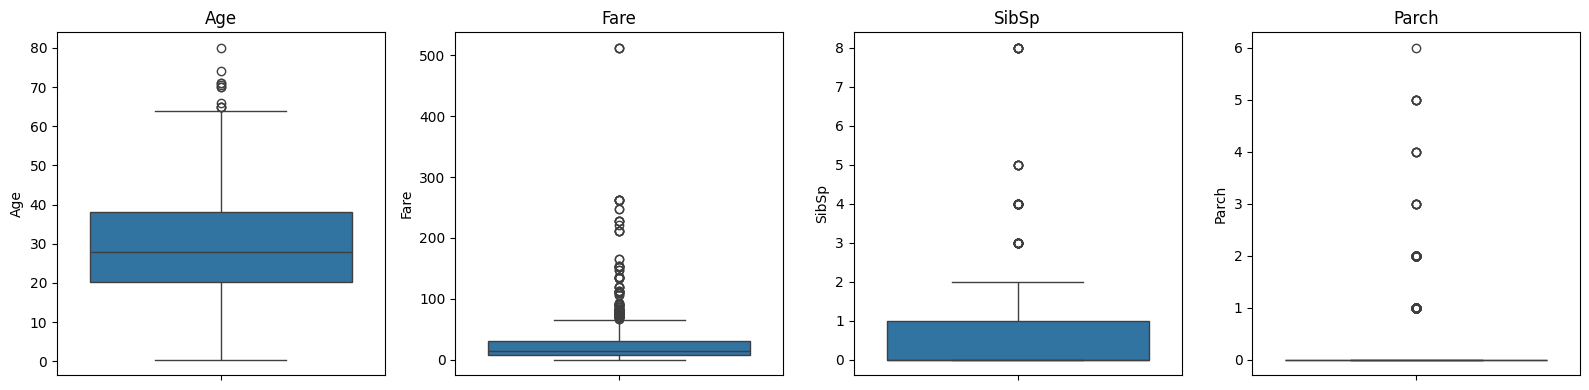

In [20]:
# Boxplots for all numerical features
numerical_features = ['Age', 'Fare', 'SibSp', 'Parch']

fig, axes = plt.subplots(1, len(numerical_features), figsize=(16, 4))
for ax, col in zip(axes, numerical_features):
    sns.boxplot(y=data[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [21]:
# IQR method to identify outliers
for col in numerical_features:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)][col]
    print(f"{col}: {len(outliers)} outliers  (lower bound={lower:.2f}, upper bound={upper:.2f})")

Age: 11 outliers  (lower bound=-6.69, upper bound=64.81)
Fare: 116 outliers  (lower bound=-26.72, upper bound=65.63)
SibSp: 46 outliers  (lower bound=-1.50, upper bound=2.50)
Parch: 213 outliers  (lower bound=0.00, upper bound=0.00)


## 3. Numerical Features Normalization

Two scaling strategies are applied to `Age` and `Fare`:
- **Min-Max Scaling** — compresses values to [0, 1]
- **Standard Scaling** — zero mean, unit variance (Z-score)

In [22]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

data_processed = data.copy()

# Fill missing Age values before scaling
data_processed['Age'] = data_processed['Age'].fillna(data_processed['Age'].median())

# Min-Max Scaling (scales to [0, 1])
minmax_scaler = MinMaxScaler()
data_processed[['Age_minmax', 'Fare_minmax']] = minmax_scaler.fit_transform(data_processed[['Age', 'Fare']])

# Standard Scaling (zero mean, unit variance)
std_scaler = StandardScaler()
data_processed[['Age_std', 'Fare_std']] = std_scaler.fit_transform(data_processed[['Age', 'Fare']])

data_processed[['Age', 'Fare', 'Age_minmax', 'Fare_minmax', 'Age_std', 'Fare_std']].describe().round(3)

,Age,Fare,Age_minmax,Fare_minmax,Age_std,Fare_std
count,891.000,891.000,891.000,891.000,891.000,891.000
mean,29.362,32.204,0.364,0.063,0.000,0.000
std,13.020,49.693,0.164,0.097,1.001,1.001
min,0.420,0.000,0.000,0.000,-2.224,-0.648
25%,22.000,7.910,0.271,0.015,-0.566,-0.489
50%,28.000,14.454,0.347,0.028,-0.105,-0.357
75%,35.000,31.000,0.435,0.061,0.433,-0.024
max,80.000,512.329,1.000,1.000,3.892,9.667


## 4. Categorical Data Encoding

| Feature | Type | Strategy |
|---|---|---|
| `Sex` | Binary nominal | Label Encoding (female=0, male=1) |
| `Embarked` | Multi-class nominal | One-Hot Encoding |
| `Pclass` | Ordinal | Already numeric — no encoding needed |

In [23]:
from sklearn.preprocessing import LabelEncoder

# Fill missing Embarked before encoding
data_processed['Embarked'] = data_processed['Embarked'].fillna(data_processed['Embarked'].mode()[0])

# Label Encoding for binary feature: Sex (male=1, female=0)
le = LabelEncoder()
data_processed['Sex_encoded'] = le.fit_transform(data_processed['Sex'])

# One-Hot Encoding for multi-class nominal feature: Embarked (S, C, Q)
embarked_dummies = pd.get_dummies(data_processed['Embarked'], prefix='Embarked')
data_processed = pd.concat([data_processed, embarked_dummies], axis=1)

# Ordinal feature: Pclass is already numeric (1=upper, 2=middle, 3=lower) — no encoding needed

print("Sex encoding sample:")
print(data_processed[['Sex', 'Sex_encoded']].drop_duplicates())
print("\nEmbarked one-hot encoding sample:")
print(data_processed[['Embarked', 'Embarked_C', 'Embarked_Q', 'Embarked_S']].drop_duplicates().sort_values('Embarked'))

Sex encoding sample:
      Sex  Sex_encoded
0    male            1
1  female            0

Embarked one-hot encoding sample:
  Embarked  Embarked_C  Embarked_Q  Embarked_S
1        C        True       False       False
5        Q       False        True       False
0        S       False       False        True


---

## Source Code

The full source code for this notebook is available on GitHub:

> **[https://github.com/jasonchanjj123/titanic-dataset-classwork](https://github.com/jasonchanjj123/titanic-dataset-classwork)**

Visit the repository for the complete notebook and dataset.